# Student Performance Prediction — Model Selection and Evaluation

This notebook compares multiple regression models for predicting the final student grade (`G3`) under two feature scenarios:

- **Full feature set:** includes `G1` and `G2`
- **Early-prediction feature set:** excludes `G1` and `G2`

Model selection is based primarily on cross-validated **Mean Absolute Error (MAE)**, with RMSE and R² used as supporting metrics. The hold-out test set is reserved for final evaluation after model selection and tuning.


## Imports


In [24]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.inspection import permutation_importance


## Load Data

The raw Mathematics dataset is loaded directly so that model development starts from the original feature representation.


In [25]:
DATA_PATH = Path("../data/raw/student-mat.csv")

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Shape: {df.shape}")
df.head()


Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Target and Modeling Scenarios

`G3` is the regression target.

Two feature sets are evaluated:

- `X_full`: all predictors except `G3`
- `X_early`: excludes `G1` and `G2`

The comparison quantifies how much predictive performance depends on previous-period grades.


In [26]:
TARGET = "G3"

y = df[TARGET]

X_full = df.drop(columns=[TARGET])
X_early = df.drop(columns=["G1", "G2", TARGET])

scenarios = {
    "Full": X_full,
    "Early": X_early,
}

print(f"Full feature set:  {X_full.shape}")
print(f"Early feature set: {X_early.shape}")


Full feature set:  (395, 32)
Early feature set: (395, 30)


## Shared Train–Test Split

A single set of train/test row indices is used for both feature scenarios. This ensures that Full and Early models are evaluated on the same students.


In [27]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
)

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print(f"Training rows: {len(train_idx)}")
print(f"Test rows:     {len(test_idx)}")


Training rows: 316
Test rows:     79


## Preprocessing Function

Numerical variables are median-imputed and standardized. Categorical variables are imputed with the most frequent category and one-hot encoded.

The preprocessor is constructed inside each model pipeline so that all transformations are fitted within the corresponding training fold during cross-validation.


In [28]:
def build_preprocessor(X):
    categorical_features = (
        X.select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    numerical_features = (
        X.select_dtypes(include=["number"])
        .columns
        .tolist()
    )

    numerical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numerical_pipeline, numerical_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )


## Candidate Models

The candidate set includes a naive baseline, two linear models, and two nonlinear ensemble methods:

- Dummy Regressor
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting


In [29]:
models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
}


## Cross-Validation Setup

Five-fold shuffled cross-validation is used on the training portion of the data.

The evaluation metrics are:

- **MAE:** primary model-selection metric
- **RMSE:** gives greater weight to large errors
- **R²:** measures explained variance relative to a constant baseline


In [30]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2",
}


## Cross-Validated Model Comparison

Each estimator is evaluated as a complete preprocessing-and-model pipeline.

Training and validation errors are both retained so that large generalization gaps can be identified.


In [31]:
def evaluate_models(
    X_train,
    y_train,
    scenario_name,
    models,
    cv,
):
    rows = []

    for model_name, estimator in models.items():
        pipeline = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor(X_train)),
                ("model", clone(estimator)),
            ]
        )

        scores = cross_validate(
            estimator=pipeline,
            X=X_train,
            y=y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1,
        )

        train_mae = -scores["train_mae"]
        cv_mae = -scores["test_mae"]

        train_rmse = np.sqrt(-scores["train_mse"])
        cv_rmse = np.sqrt(-scores["test_mse"])

        rows.append(
            {
                "Scenario": scenario_name,
                "Model": model_name,
                "Train MAE": train_mae.mean(),
                "CV MAE": cv_mae.mean(),
                "CV MAE Std": cv_mae.std(),
                "Train RMSE": train_rmse.mean(),
                "CV RMSE": cv_rmse.mean(),
                "CV RMSE Std": cv_rmse.std(),
                "CV R2": scores["test_r2"].mean(),
                "MAE Gap": cv_mae.mean() - train_mae.mean(),
            }
        )

    return pd.DataFrame(rows)


In [32]:
all_results = []

for scenario_name, X in scenarios.items():
    X_train = X.loc[train_idx]

    result = evaluate_models(
        X_train=X_train,
        y_train=y_train,
        scenario_name=scenario_name,
        models=models,
        cv=cv,
    )

    all_results.append(result)

results_df = (
    pd.concat(all_results, ignore_index=True)
    .sort_values(["Scenario", "CV MAE"])
)

results_df.round(3)


,Scenario,Model,Train MAE,CV MAE,CV MAE Std,Train RMSE,CV RMSE,CV RMSE Std,CV R2,MAE Gap
8,Early,Random Forest,1.094,2.934,0.298,1.477,3.925,0.297,0.212,1.840
9,Early,Gradient Boosting,1.386,3.168,0.254,1.792,4.043,0.205,0.158,1.783
5,Early,Dummy Mean,3.377,3.403,0.629,4.578,4.563,0.634,-0.035,0.026
7,Early,Ridge,2.893,3.506,0.382,3.783,4.584,0.325,-0.080,0.613
6,Early,Linear Regression,2.894,3.523,0.382,3.783,4.607,0.327,-0.092,0.629
3,Full,Random Forest,0.349,0.939,0.190,0.565,1.478,0.443,0.892,0.589
4,Full,Gradient Boosting,0.428,1.039,0.195,0.620,1.579,0.378,0.876,0.611
2,Full,Ridge,1.152,1.381,0.227,1.642,1.977,0.358,0.806,0.229
1,Full,Linear Regression,1.155,1.393,0.230,1.642,1.987,0.361,0.804,0.238
0,Full,Dummy Mean,3.377,3.403,0.629,4.578,4.563,0.634,-0.035,0.026


## Cross-Validated MAE Comparison

Lower MAE indicates better predictive performance. The comparison also shows the effect of including versus excluding `G1` and `G2`.


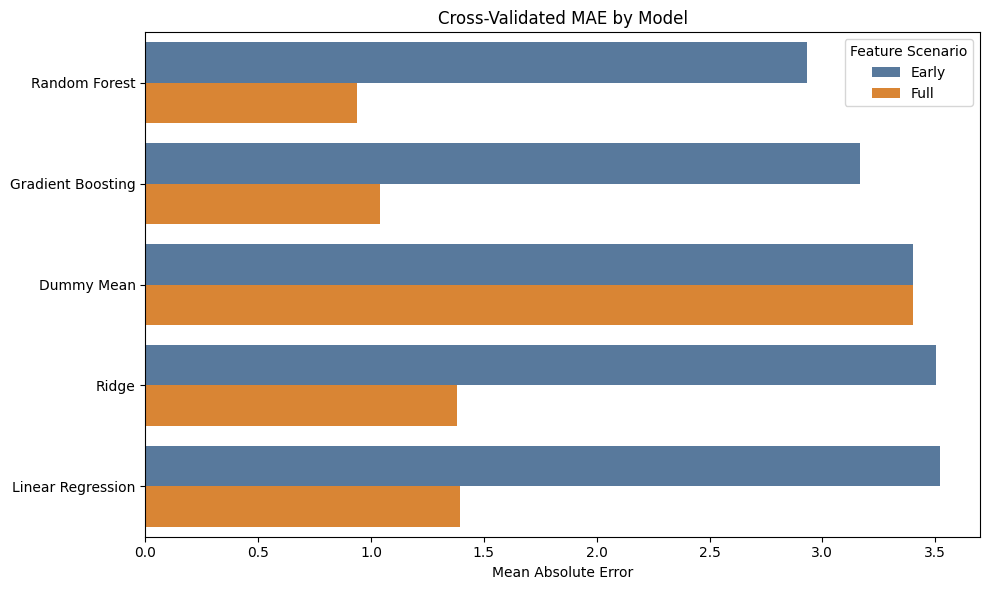

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="CV MAE",
    y="Model",
    hue="Scenario",
    palette=["#4C78A8", "#F58518"],
)

plt.title("Cross-Validated MAE by Model")
plt.xlabel("Mean Absolute Error")
plt.ylabel("")
plt.legend(title="Feature Scenario")
plt.tight_layout()
plt.show()


## Baseline and Best Candidate per Scenario

The Dummy Regressor provides a minimum benchmark. The strongest non-dummy model in each scenario is selected using cross-validated MAE.


In [34]:
baseline_results = results_df[
    results_df["Model"] == "Dummy Mean"
]

baseline_results[
    ["Scenario", "CV MAE", "CV RMSE", "CV R2"]
].round(3)


,Scenario,CV MAE,CV RMSE,CV R2
5,Early,3.403,4.563,-0.035
0,Full,3.403,4.563,-0.035


In [35]:
candidate_results = results_df[
    results_df["Model"] != "Dummy Mean"
]

best_candidates = (
    candidate_results
    .sort_values("CV MAE")
    .groupby("Scenario", as_index=False)
    .first()
)

best_candidates[
    [
        "Scenario",
        "Model",
        "CV MAE",
        "CV RMSE",
        "CV R2",
        "MAE Gap",
    ]
].round(3)


,Scenario,Model,CV MAE,CV RMSE,CV R2,MAE Gap
0,Early,Random Forest,2.934,3.925,0.212,1.840
1,Full,Random Forest,0.939,1.478,0.892,0.589


## Hyperparameter Search

Compact search spaces are used for models with meaningful tuning parameters. Selection remains based on MAE.


In [36]:
param_grids = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1, 10, 100],
    },

    "Random Forest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 1.0],
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_leaf": [1, 3],
    },
}


In [37]:
def tune_selected_model(
    X_train,
    y_train,
    model_name,
    models,
    cv,
):
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(X_train)),
            ("model", clone(models[model_name])),
        ]
    )

    if model_name not in param_grids:
        pipeline.fit(X_train, y_train)
        return pipeline, {}

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )

    search.fit(X_train, y_train)

    print(f"Best CV MAE: {-search.best_score_:.3f}")
    print("Best parameters:", search.best_params_)

    return search.best_estimator_, search.best_params_


## Tune the Selected Model for Each Scenario


In [38]:
final_models = {}
tuning_results = {}

for _, row in best_candidates.iterrows():
    scenario_name = row["Scenario"]
    model_name = row["Model"]

    print(f"\n{scenario_name} scenario")
    print(f"Selected model: {model_name}")

    X = scenarios[scenario_name]
    X_train = X.loc[train_idx]

    best_model, best_params = tune_selected_model(
        X_train=X_train,
        y_train=y_train,
        model_name=model_name,
        models=models,
        cv=cv,
    )

    final_models[scenario_name] = best_model
    tuning_results[scenario_name] = best_params



Early scenario
Selected model: Random Forest
Best CV MAE: 2.934
Best parameters: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}

Full scenario
Selected model: Random Forest
Best CV MAE: 0.936
Best parameters: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 500}


## Final Hold-Out Evaluation

The selected model for each scenario is evaluated once on the reserved test set.

This provides the final out-of-sample comparison between the Full and Early feature sets.


In [39]:
test_results = []
predictions = {}

for scenario_name, model in final_models.items():
    X = scenarios[scenario_name]

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    predictions[scenario_name] = test_pred

    test_results.append(
        {
            "Scenario": scenario_name,
            "Train MAE": mean_absolute_error(y_train, train_pred),
            "Test MAE": mean_absolute_error(y_test, test_pred),
            "Train RMSE": np.sqrt(
                mean_squared_error(y_train, train_pred)
            ),
            "Test RMSE": np.sqrt(
                mean_squared_error(y_test, test_pred)
            ),
            "Test R2": r2_score(y_test, test_pred),
        }
    )

test_results_df = pd.DataFrame(test_results)

test_results_df.round(3)


,Scenario,Train MAE,Test MAE,Train RMSE,Test RMSE,Test R2
0,Early,1.337,3.036,1.846,3.813,0.291
1,Full,0.412,1.209,0.703,2.006,0.804


## Actual vs Predicted

The diagonal reference line represents perfect predictions. Points farther from the line correspond to larger prediction errors.


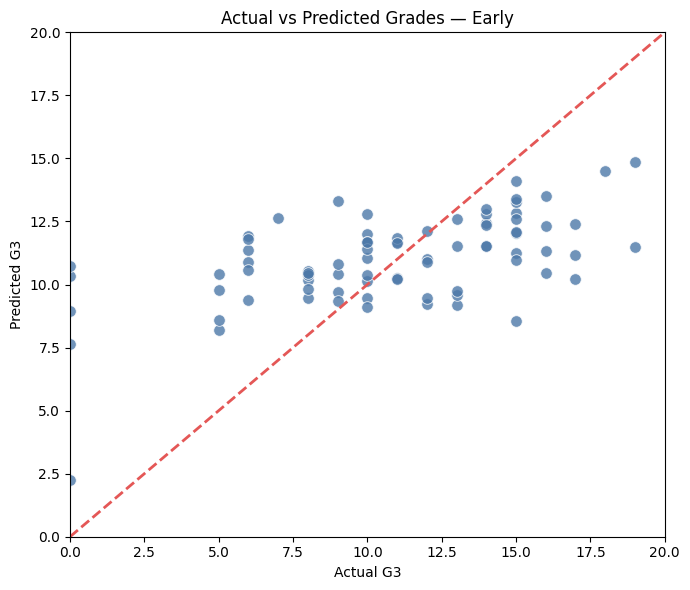

In [40]:
scenario_name = "Early"
y_pred = predictions[scenario_name]

plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="#4C78A8",
    s=70,
    alpha=0.8,
)

plt.plot(
    [0, 20],
    [0, 20],
    linestyle="--",
    color="#E45756",
    linewidth=2,
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title(f"Actual vs Predicted Grades — {scenario_name}")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()


## Residual Diagnostics

Residuals are defined as:

`actual - predicted`

A well-behaved model should not show a strong systematic pattern in residuals across the prediction range.


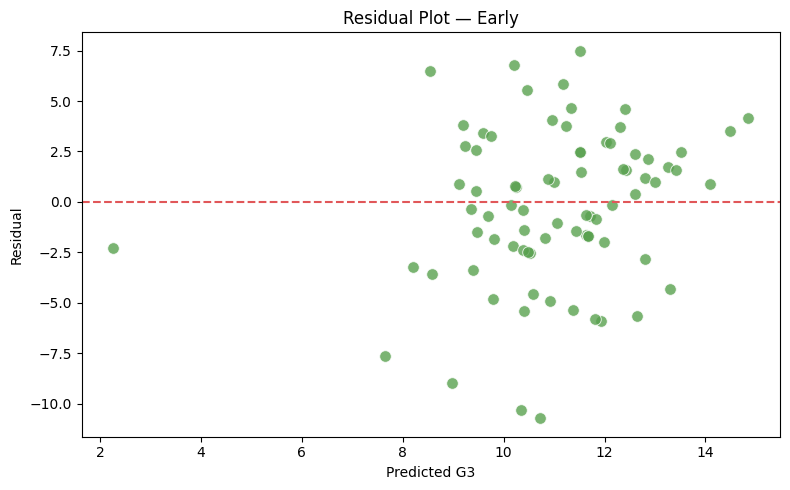

In [41]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    color="#59A14F",
    s=70,
    alpha=0.8,
)

plt.axhline(
    y=0,
    color="#E15759",
    linestyle="--",
)

plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.title(f"Residual Plot — {scenario_name}")
plt.tight_layout()
plt.show()


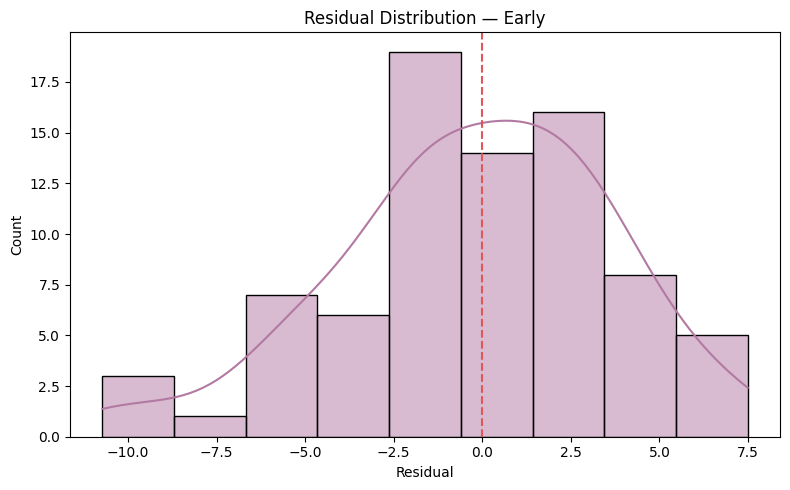

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True,
    color="#B279A2",
)

plt.axvline(
    0,
    color="#E15759",
    linestyle="--",
)

plt.xlabel("Residual")
plt.title(f"Residual Distribution — {scenario_name}")
plt.tight_layout()
plt.show()


## Permutation Feature Importance

Permutation importance measures the decrease in predictive performance when a feature is randomly shuffled.

The result indicates which original input features the fitted model relies on most strongly. It should not be interpreted as evidence of causality.


In [43]:
X = scenarios[scenario_name]
X_test = X.loc[test_idx]
model = final_models[scenario_name]

importance = permutation_importance(
    estimator=model,
    X=X_test,
    y=y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": importance.importances_mean,
        "Std": importance.importances_std,
    }
).sort_values(
    "Importance",
    ascending=False,
)

importance_df.head(15)


,Feature,Importance,Std
14,failures,0.463827,0.138303
29,absences,0.336304,0.159243
25,goout,0.086967,0.043355
1,sex,0.081720,0.033615
6,Medu,0.061488,0.021530
15,schoolsup,0.056838,0.033125
8,Mjob,0.054128,0.036528
11,guardian,0.047083,0.031890
22,romantic,0.036182,0.025728
10,reason,0.034680,0.027098


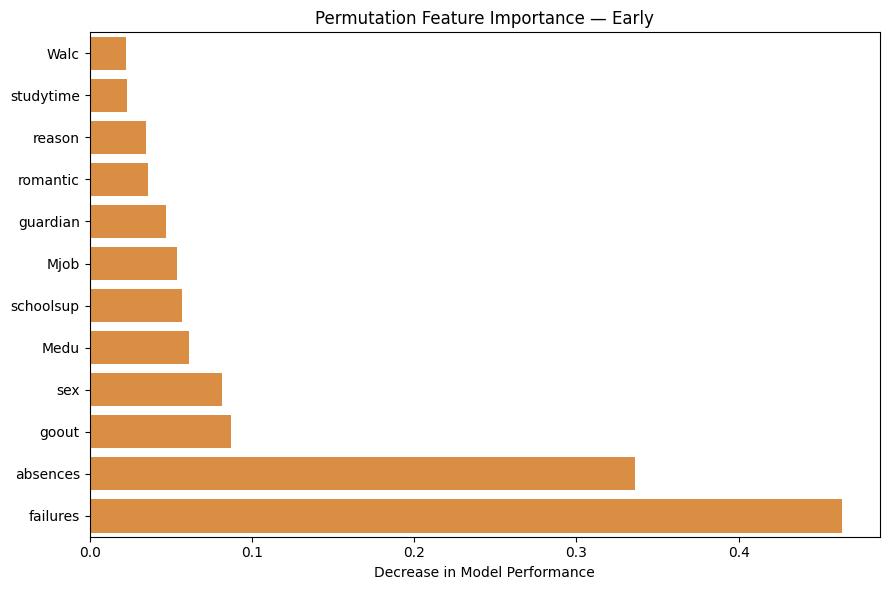

In [44]:
top_features = (
    importance_df
    .head(12)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="#F28E2B",
)

plt.title(f"Permutation Feature Importance — {scenario_name}")
plt.xlabel("Decrease in Model Performance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Modeling Summary

This workflow provides a controlled comparison of regression models across two feature scenarios.

The key outputs to report after execution are:

- the strongest cross-validated model in each scenario
- the corresponding MAE, RMSE, and R² values
- the train-to-validation error gap
- the final hold-out test performance
- the performance difference between the Full and Early feature sets
- the most influential features according to permutation importance

The final model choice should consider both predictive accuracy and the intended prediction setting. A Full model may achieve lower error because `G1` and `G2` carry strong academic signal, while the Early model addresses a more difficult prediction problem without those previous grades.


In [45]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../models/student_performance_model.pkl")

joblib.dump(
    final_models["Full"],
    MODEL_PATH
)

print(MODEL_PATH.exists())

True


In [46]:
loaded_model = joblib.load(MODEL_PATH)

X_full_test = X_full.loc[test_idx]

loaded_predictions = loaded_model.predict(
    X_full_test
)

np.allclose(
    loaded_predictions,
    predictions["Full"]
)

True

In [47]:
import json

METADATA_PATH = Path(
    "../models/model_metadata.json"
)

FULL_FEATURES = X_full.columns.tolist()

metadata = {
    "target": "G3",
    "scenario": "Full",
    "model": "RandomForestRegressor",
    "features": FULL_FEATURES,
    "test_mae": float(
        test_results_df.loc[
            test_results_df["Scenario"] == "Full",
            "Test MAE"
        ].iloc[0]
    ),
    "test_rmse": float(
        test_results_df.loc[
            test_results_df["Scenario"] == "Full",
            "Test RMSE"
        ].iloc[0]
    ),
    "test_r2": float(
        test_results_df.loc[
            test_results_df["Scenario"] == "Full",
            "Test R2"
        ].iloc[0]
    ),
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )